# Resistance Model

In [1]:
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from axiom.config import DATA_DIR

## Load the Data

In [2]:
TICKER = "SPY"

SAVE_FN = f"{TICKER}_{datetime.now().strftime('%Y-%m-%d')}.csv"
# SAVE_FN = "SPY_2024-07-14.csv"

SAVE_FP = DATA_DIR.joinpath("daily", SAVE_FN)

In [3]:
# GET the data

from axiom.mdata.equity import get_daily_price_history, CandleList

data: CandleList = await get_daily_price_history(TICKER)

# Convert to DataFrame
df = pd.DataFrame.from_records([candle.dict() for candle in data.candles])
df.to_csv(SAVE_FP, index=False)

In [4]:
# Load the data
df = pd.read_csv(SAVE_FP)

## Process the data

In [5]:
# Filter columns
columns = ["datetime", "high", "low"]
df = df[columns]

# Convert int to datetime
df["datetime"] = pd.to_datetime(df["datetime"], unit="ms")

# Add a new column for the day of the week, 0=Monday, 6=Sunday
df["day"] = df["datetime"].dt.dayofweek

### Round the values

0-100 -> 0.1
100-200 -> 0.2
200-300 -> 0.3
...

This creates a more general resistance model that can be applied at different price levels.
It isn't perfect, but it's a good starting point.

In [6]:
# Round the high and low
def round_to_tick(value):
    tick = value // 100 or 1
    round_to = tick / 10
    return round(value / round_to) * round_to


# Apply the custom rounding to 'high' and 'low' columns
df["high"] = df["high"].apply(round_to_tick)
df["low"] = df["low"].apply(round_to_tick)

In [7]:
df.tail()

,datetime,high,low,day
5031,2024-07-15 05:00:00,565.0,559.5,0
5032,2024-07-16 05:00:00,565.0,562.0,1
5033,2024-07-17 05:00:00,560.5,556.5,2
5034,2024-07-18 05:00:00,559.5,550.5,3
5035,2024-07-19 05:00:00,554.0,548.0,4


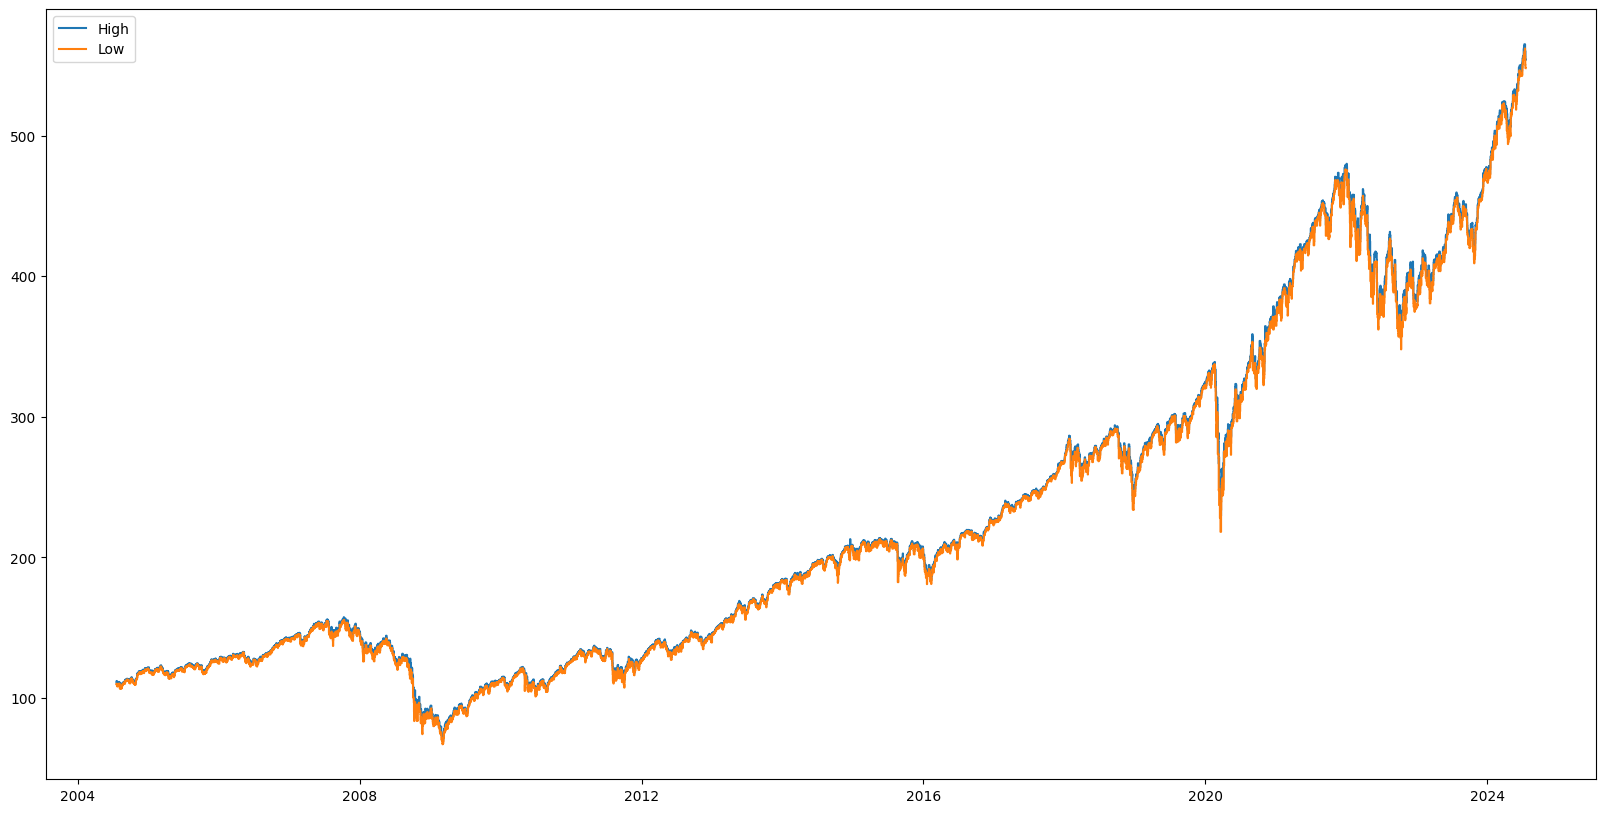

In [8]:
plt.figure(figsize=(20, 10))
plt.step(df["datetime"], df["high"], label="High")
plt.step(df["datetime"], df["low"], label="Low")
plt.legend()
plt.show()

In [9]:
# Calculate the common resistance levels
resistance_levels = df["high"].value_counts()

# Sort by most common resistance levels
resistance_levels = resistance_levels.sort_values(ascending=False)
resistance_levels.head(10)

high
209.8    14
127.4    13
210.4    13
120.0    12
210.6    12
208.2    12
132.8    12
128.4    12
111.7    11
207.4    11
Name: count, dtype: int64

## Prepare the dataset

We will use the high prices of the last 5 days ending on a friday to predict the high price of next week.

In [10]:
d_df = df.copy()

# Filter for Fridays (day == 4)
fridays = d_df[d_df["day"] == 4].reset_index(drop=True)

# Create features and labels for high and low prices
high_features = []
low_features = []
high_labels = []
low_labels = []

for i in range(1, len(fridays) - 1):
    friday_date = fridays.loc[i, "datetime"]
    next_friday_date = fridays.loc[i + 1, "datetime"]

    # Filter the last 10 trading days ending on this Friday
    last_5_days = d_df[
        (d_df["datetime"] <= friday_date) & (d_df["datetime"] > friday_date - pd.Timedelta(days=12))
        ]

    # Check if we have exactly 5 days
    if len(last_5_days) == 10:
        # Create the feature vector of the high and low prices of the last 5 days
        high_feature_vector = last_5_days["high"].values
        low_feature_vector = last_5_days["low"].values

        # Filter the next week's data
        next_week_data = d_df[
            (d_df["datetime"] > friday_date)
            & (d_df["datetime"] <= friday_date + pd.Timedelta(days=7))
            ]

        # Check if we have at least one day in the next week
        if not next_week_data.empty:
            # The labels are the maximum high price and minimum low price of the next week
            high_label = next_week_data["high"].max()
            low_label = next_week_data["low"].min()

            high_features.append(high_feature_vector)
            low_features.append(low_feature_vector)
            high_labels.append(high_label)
            low_labels.append(low_label)

# Convert to numpy arrays
high_X = np.array(high_features)
low_X = np.array(low_features)
high_y = np.array(high_labels)
low_y = np.array(low_labels)

# Verify the shapes
print("High Features shape:", high_X.shape)
print("Low Features shape:", low_X.shape)
print("High Labels shape:", high_y.shape)
print("Low Labels shape:", low_y.shape)

High Features shape: (695, 10)
Low Features shape: (695, 10)
High Labels shape: (695,)
Low Labels shape: (695,)


## Train the model

In [29]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [30]:
# High Model Training and Testing
X_high_train, X_high_test, y_high_train, y_high_test = train_test_split(
    high_X, high_y, test_size=0.5, random_state=42
)

# Standardize the high features
scaler_high = StandardScaler()
X_high_train_scaled = scaler_high.fit_transform(X_high_train)
X_high_test_scaled = scaler_high.transform(X_high_test)

# Train the XGBoost model for high data
xgb_model_high = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model_high.fit(X_high_train_scaled, y_high_train)

# Predictions
y_pred_train_high_xgb = xgb_model_high.predict(X_high_train_scaled)
y_pred_test_high_xgb = xgb_model_high.predict(X_high_test_scaled)

# Performance evaluation for high model
print("XGBoost Regressor Performance for High Data:")
print(f"Train MSE: {mean_squared_error(y_high_train, y_pred_train_high_xgb):.4f}")
print(f"Test MSE: {mean_squared_error(y_high_test, y_pred_test_high_xgb):.4f}")
print(f"Train R2: {r2_score(y_high_train, y_pred_train_high_xgb):.4f}")
print(f"Test R2: {r2_score(y_high_test, y_pred_test_high_xgb):.4f}")
print()

XGBoost Regressor Performance for High Data:
Train MSE: 0.3408
Test MSE: 26.6598
Train R2: 1.0000
Test R2: 0.9980



In [31]:
# Low Model Training and Testing
# Split the low data
X_low_train, X_low_test, y_low_train, y_low_test = train_test_split(
    low_X, low_y, test_size=0.7, random_state=42
)

# Standardize the low features
scaler_low = StandardScaler()
X_low_train_scaled = scaler_low.fit_transform(X_low_train)
X_low_test_scaled = scaler_low.transform(X_low_test)

# Train the XGBoost model for low data
xgb_model_low = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model_low.fit(X_low_train_scaled, y_low_train)

# Predictions
y_pred_train_low_xgb = xgb_model_low.predict(X_low_train_scaled)
y_pred_test_low_xgb = xgb_model_low.predict(X_low_test_scaled)

# Performance evaluation for low model
print("XGBoost Regressor Performance for Low Data:")
print(f"Train MSE: {mean_squared_error(y_low_train, y_pred_train_low_xgb):.4f}")
print(f"Test MSE: {mean_squared_error(y_low_test, y_pred_test_low_xgb):.4f}")
print(f"Train R2: {r2_score(y_low_train, y_pred_train_low_xgb):.4f}")
print(f"Test R2: {r2_score(y_low_test, y_pred_test_low_xgb):.4f}")

XGBoost Regressor Performance for Low Data:
Train MSE: 0.2902
Test MSE: 56.1965
Train R2: 1.0000
Test R2: 0.9958


In [32]:
# # Test the model with manual data
# # This data is for the week of 2024 July 8th to 12th
# last_days_high = np.array([556.5, 557.0, 561.5, 562.5, 563.5])
# last_days_low = np.array([554.0, 555.5, 557.0, 556.0, 557.0])

# In the last 10 rows, get the index of the last "4" day
last_friday_index = df[df["day"] == 4].index[-1]

# Get the highs and lows of the last 5 days ending on the last "4" day
last_days = df.loc[last_friday_index - 9: last_friday_index]
last_days_high = last_days["high"].values
last_days_low = last_days["low"].values
last_days_high, last_days_low

(array([556.5, 557. , 561.5, 562.5, 563.5, 565. , 565. , 560.5, 559.5,
        554. ]),
 array([554. , 555.5, 557. , 556. , 557. , 559.5, 562. , 556.5, 550.5,
        548. ]))

In [33]:
# Predict the next week's high and low prices
last_days_scaled_high = scaler_high.transform(last_days_high.reshape(1, -1))
next_week_high = xgb_model_high.predict(last_days_scaled_high)
print("Next week's high price prediction:", next_week_high[0])

last_days_scaled_low = scaler_low.transform(last_days_low.reshape(1, -1))
next_week_low = xgb_model_low.predict(last_days_scaled_low)
print("Next week's low price prediction:", next_week_low[0])

Next week's high price prediction: 530.60767
Next week's low price prediction: 523.19226


## Save the models

In [34]:
xgb_model_high_fp = DATA_DIR.joinpath("models", f"xgb_resistance_model_high_2_{TICKER}.json")
xgb_model_low_fp = DATA_DIR.joinpath("models", f"xgb_resistance_model_low_2_{TICKER}.json")

# Save the models
xgb_model_high.save_model(xgb_model_high_fp)
xgb_model_low.save_model(xgb_model_low_fp)

# Load the models
# xgb_model_high = XGBRegressor()
# xgb_model_high.load_model(xgb_model_high_fp)
#
# xgb_model_low = XGBRegressor()
# xgb_model_low.load_model(xgb_model_low_fp)

### Pipeline

In [35]:
from axiom.models import WeeklyResistanceModel

In [36]:
# Train the pipeline
pipeline = WeeklyResistanceModel("SPY")
pipeline.train(high_X, high_y, low_X, low_y)

# Make predictions
# last_days_high = [556.5, 557.0, 561.5, 562.5, 563.5]
# last_days_low = [554.0, 555.5, 557.0, 556.0, 557.0]
next_week_high, next_week_low = pipeline.predict(last_days_high, last_days_low)
print("Next week's high price prediction:", next_week_high)
print("Next week's low price prediction:", next_week_low)

Next week's high price prediction: 531.7519
Next week's low price prediction: 523.2247


In [37]:
weekly_resistance_model_high_fp = DATA_DIR.joinpath(
    "models", f"weekly_resistance_model_high_2_{TICKER}.json"
)
weekly_resistance_model_low_fp = DATA_DIR.joinpath(
    "models", f"weekly_resistance_model_low_2_{TICKER}.json"
)

# Save the pipeline
pipeline.save(weekly_resistance_model_high_fp, weekly_resistance_model_low_fp)

# Load the pipeline
pipeline = WeeklyResistanceModel.load(
    "SPY", weekly_resistance_model_high_fp, weekly_resistance_model_low_fp
)

# Make predictions
# last_days_high = [556.5, 557.0, 561.5, 562.5, 563.5]
# last_days_low = [554.0, 555.5, 557.0, 556.0, 557.0]
next_week_high, next_week_low = pipeline.predict(last_days_high, last_days_low)
print("Next week's high price prediction:", next_week_high)
print("Next week's low price prediction:", next_week_low)

Next week's high price prediction: 531.7519
Next week's low price prediction: 523.2247
